Question NO 1
All working for this question must be carried out and submitted in the Jupyter Notebook, using your
group's chosen dataset.
a) Choose one continuous numerical variable from your dataset that you find analytically interesting. In
the notebook, compute and display the mean, median, mode, range, and standard deviation for this
variable. In a short paragraph, interpret these statistics in the context of your dataset — explain what the
mean and standard deviation tell you about the variable's typical value and spread, and state whether the
mean or the median is the more appropriate measure of centre given the variable's skewness. [2 marks]
b) Using the same variable from part (a), build a well-formatted histogram with exactly eight (8) equalwidth classes. Include a descriptive title and clearly labelled axes (variable name and units on the x-axis;
frequency or relative frequency on the y-axis). In a paragraph, describe and interpret the distribution
shown: its overall shape (symmetric, positively or negatively skewed, bimodal, or uniform), the
approximate centre and spread, and any notable features such as outliers, gaps, or unusual peaks. [3
marks]


In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv(r'C:\Users\devel\Desktop\college\assesments\mathematicalfoundation\groupproject\Students Performance.csv')
math = df['math score']
mean = math.mean()
median = math.median()
mode = math.mode()[0]
range = math.max() - math.min()
std = math.std()
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode: {mode}")
print(f"Range: {range}")
print(f"Standard deviation: {std:.2f}")

summary = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Mode', 'Range', 'Std Dev'],
    'Value': [mean, median, mode, range, std]
})
summary

Mean: 66.09
Median: 66.00
Mode: 65
Range: 100
Standard deviation: 15.16


,Statistic,Value
0,Mean,66.08900
1,Median,66.00000
2,Mode,65.00000
3,Range,100.00000
4,Std Dev,15.16308


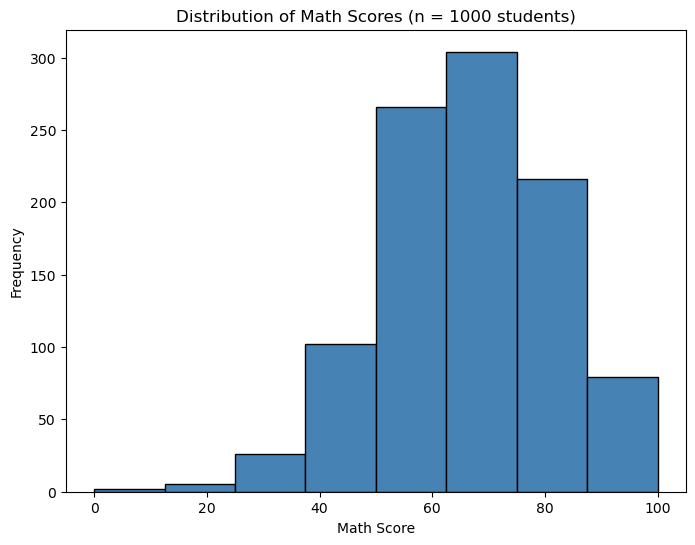

In [16]:
plt.figure(figsize=(8,6))
plt.hist(df['math score'], bins=8, edgecolor='black', color='steelblue')
plt.title('Distribution of Math Scores (n = 1000 students)')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.savefig(r'C:\Users\devel\Desktop\college\assesments\mathematicalfoundation\groupproject\math_score_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

Question NO 2
All computations must be performed in Jupyter Notebook. The confidence interval must be constructed
manually using the formula below, not via a built-in library function. Use scipy.stats.t to obtain critical
values only.
In this task, you are required to analyse your data and construct a confidence interval to estimate the
population difference in means between two groups.
The following formula is used to construct the confidence interval.
(𝑥1̅ − 𝑥̅2
) ± 𝑡 × √
𝑠1
2
(𝑛1 − 1) + 𝑠2
2
(𝑛2 − 1)
𝑛1 + 𝑛2 − 2
× √
1
𝑛1
+
1
𝑛2
(Note: degrees of freedom = 𝑛1 + 𝑛2 − 2).

a) Identify two distinct groups within your dataset that you will compare. These groups must be
formed using a categorical variable present in the dataset (e.g., gender, product category, genre,
diabetes outcome). State which two groups you are comparing, which numerical variable you
are analysing, and provide a brief justification of why this comparison is analytically meaningful
in the context of the dataset. [1 mark]
b) Construct the 90% confidence interval for the difference in population means. Assume that the
population variances are unknown but equal, and that both populations are normally
distributed. Your code must clearly show each step: computation of the pooled variance, the
standard error, the critical value, and the final interval. Display the lower and upper bounds of
the interval. [3 marks]
c) Interpret the confidence interval in the context of the data. [1 mark]


In [18]:

female = df[df['gender'] == 'female']['math score']
male = df[df['gender'] == 'male']['math score']

n1, n2 = len(female), len(male)
x1_bar, x2_bar = female.mean(), male.mean()
s1, s2 = female.std(ddof=1), male.std(ddof=1)

pooled_var = ((s1**2) * (n1 - 1) + (s2**2) * (n2 - 1)) / (n1 + n2 - 2)

se = (pooled_var ** 0.5) * ((1/n1 + 1/n2) ** 0.5)

dof = n1 + n2 - 2
t_crit = stats.t.ppf(0.95, dof)


diff = x1_bar - x2_bar
margin = t_crit * se

lower = diff - margin
upper = diff + margin

summary_table = pd.DataFrame({
    'Quantity': ['n (Female)', 'n (Male)', 'Mean (Female)', 'Mean (Male)',
                 'Std Dev (Female)', 'Std Dev (Male)', 'Pooled Variance',
                 'Standard Error', 'Degrees of Freedom', 'Critical t-value',
                 'Difference in Means (F - M)', 'Lower Bound (90% CI)', 'Upper Bound (90% CI)'],
    'Value': [n1, n2, round(x1_bar,2), round(x2_bar,2),
              round(s1,2), round(s2,2), round(pooled_var,4),
              round(se,4), dof, round(t_crit,4),
              round(diff,4), round(lower,4), round(upper,4)]
})

summary_table




,Quantity,Value
0,n (Female),518.0000
1,n (Male),482.0000
2,Mean (Female),63.6300
3,Mean (Male),68.7300
4,Std Dev (Female),15.4900
5,Std Dev (Male),14.3600
6,Pooled Variance,223.6550
7,Standard Error,0.9465
8,Degrees of Freedom,998.0000
9,Critical t-value,1.6464
